# 07 · Batteries: a constant-voltage pack, an equivalent circuit, and why voltage sag sizes the Halo's pack

The repository has two battery classes with the same contract but different operating inputs, so they are separate
classes (tutorial 04): `Battery` (constant open-circuit voltage and resistance, 65 lines) and `EquivalentCircuitBattery`
(state-of-charge-dependent OCV, an R0 + 2 RC circuit, temperature and ageing, series/parallel cells, 312 lines), with the
cell data and fits in `powertrain/cells.py` and `data/batteries/`. This notebook builds both up from the equations, shows
the one subtle point of battery models in an optimizer (the power equation has two roots), and ends with a small sizing
problem that reproduces the Halo's central battery result: the pack is sized by voltage at the end of the engine-out
hover, not by energy.

**In this notebook**
1. `Battery`: terminal voltage, chemical versus terminal power, SOC, and its mass.
2. The power equation has two roots: which one is physical, and how the code selects it.
3. The 50G cell: OCV data and polynomial, resistance data and the fitted R(SOC, T).
4. `EquivalentCircuitBattery`: pack scaling, ratings, ageing, and the exact RC solution over an interval.
5. A pulse, numerically: hover, cruise, then an engine-out hover from 30 % SOC.
6. Sizing the pack: energy versus end-of-hover voltage.
7. How the Halo builds its pack.

**Run time:** about 10 seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.battery_ecm import (EquivalentCircuitBattery, inr21700_50g_cell,
                                                                inr21700_50g_ocv_model, inr21700_50g_resistance_model)
from aircraft_closure.powertrain import cells

## 1. The constant battery

$V = V_\text{oc} - I R$, positive current discharging. Terminal power $VI$ goes to the bus; chemical power $V_\text{oc} I$ comes out
of storage; the difference $I^2R$ is heat. SOC falls by chemical energy over capacity, never by terminal energy:

In [2]:
print(inspect.getsource(Battery.evaluate))
pack = Battery(energy_capacity_J=50 * 3.6e6, voltage_open_circuit_V=800.0, resistance_ohm=0.1)
r = pack.evaluate(current_A=300.0, soc=0.9, duration_s=60.0)
print(r)
check("chemical = terminal + loss", abs(r.power_chemical_W - (r.power_electric_W + r.power_loss_W)) < 1e-6)
check("charging (negative current) still heats the pack", pack.evaluate(-300.0, 0.5).power_loss_W > 0)

    def evaluate(self, current_A, soc, duration_s=0.0):
        # Chemical depletion includes resistive heating; terminal power alone
        # would underestimate SOC depletion. Negative current reverses depletion
        # while Joule heating remains positive. Never clamp SOC inside the model.
        voltage_V = self.voltage_open_circuit_V - current_A * self.resistance_ohm
        power_chemical_W = self.voltage_open_circuit_V * current_A
        return BatteryResult(voltage_V, current_A, voltage_V * current_A,
                             current_A**2 * self.resistance_ohm, power_chemical_W,
                             soc - power_chemical_W * duration_s / self.energy_capacity_J)

BatteryResult(voltage_V=770.0, current_A=300.0, power_electric_W=231000.0, power_loss_W=9000.0, power_chemical_W=240000.0, soc_next=0.8200000000000001)
PASS  chemical = terminal + loss
PASS  charging (negative current) still heats the pack


Its mass is the larger of an energy-sized and a power-sized mass, $\max(E/e,\ P_\text{max}/p)$, exact by default and a `softmax`
when the caller sizes energy and power together (`mass_smoothing_kg`), which is what tutorial 18's coupled sizing does.

## 2. Two roots, and how the code picks the right one

A flight point knows the **power** the bus needs from the battery, not the current. With $V = V^* - I R$:

$$P = V I = V^* I - R I^2 \quad\Longrightarrow\quad R I^2 - V^* I + P = 0, \qquad I = \frac{V^* \mp \sqrt{V^{*2} - 4RP}}{2R}$$

Two currents deliver the same power: a low-current, high-voltage root (the physical operating point) and a high-current,
low-voltage root (more than half the voltage dropped in the cell). Beyond $P_\text{max} = V^{*2}/4R$, the *matched-load*
power, there is no solution.

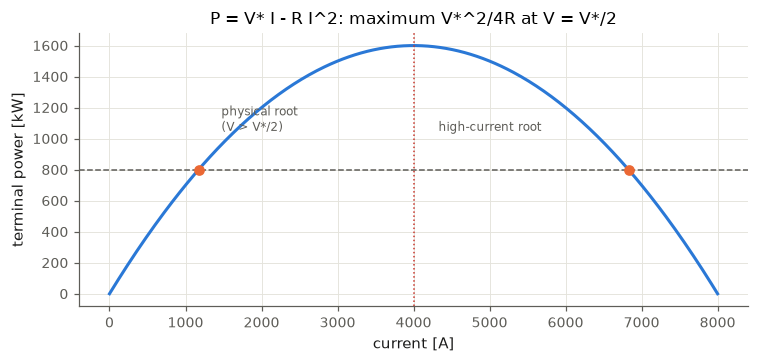

In [3]:
currents = onp.linspace(0, 8000, 400)
power = 800 * currents - 0.1 * currents**2
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(currents, power / 1e3, color=blue, lw=2)
ax.axhline(800e3 / 1e3, color=ink_muted, lw=1, ls="--")
low = (800 - onp.sqrt(800**2 - 4 * 0.1 * 800e3)) / 0.2
high = (800 + onp.sqrt(800**2 - 4 * 0.1 * 800e3)) / 0.2
ax.plot([low, high], [800, 800], "o", color=orange)
ax.annotate("physical root\n(V > V*/2)", (low, 800), xytext=(low + 300, 1050), fontsize=8, color=ink_muted)
ax.annotate("high-current root", (high, 800), xytext=(high - 2500, 1050), fontsize=8, color=ink_muted)
ax.axvline(800 / 0.2, color=red, lw=1, ls=":")
ax.set(xlabel="current [A]", ylabel="terminal power [kW]", title="P = V* I - R I^2: maximum V*^2/4R at V = V*/2")
plt.tight_layout(); plt.show()

In a closed-form code you would just take the minus sign. In an all-at-once problem the current is a **variable** with an equality
$VI = P$, and IPOPT could land on either root. The flight point therefore adds one inequality,
`battery.voltage_V / battery.voltage_driving_V >= 0.5` ($V \ge V^*/2$), which excludes the high-current branch and, as a
by-product, enforces $P \le P_\text{max}$. Demonstration, starting the solver close to each root:

In [4]:
def current_for_power(power_W, init_guess_A, branch_constraint):
    o = asb.Opti()
    current_A = o.variable(init_guess=init_guess_A, scale=100.0)
    state = pack.evaluate(current_A, soc=0.9)
    o.subject_to(state.power_electric_W / power_W == 1)
    if branch_constraint:
        o.subject_to(state.voltage_V / pack.voltage_open_circuit_V >= 0.5)
    o.minimize(0)                         # a square system: no objective needed
    s = o.solve(verbose=False)
    return s.value(current_A), s.value(state.voltage_V)

outcomes = {}
for guess in (100.0, 3000.0, 7000.0):
    for branch in (False, True):
        try:
            current, voltage = current_for_power(800e3, guess, branch)
            outcomes[guess, branch] = current
            text = f"{current:7.1f} A at {voltage:6.1f} V"
        except RuntimeError as error:
            outcomes[guess, branch] = None
            text = "FAILED: " + str(error)[str(error).find("return_status"):][:50]
        print(f"start {guess:6.0f} A, branch constraint {'on ' if branch else 'off'} -> {text}")
check("without the branch constraint a high start converges to the unphysical root",
      outcomes[7000.0, False] is not None and abs(outcomes[7000.0, False] - high) < 1e-3)
check("with the branch constraint, a start below the maximum-power current lands on the physical root",
      all(abs(outcomes[g, True] - low) < 1e-3 for g in (100.0, 3000.0)))

start    100 A, branch constraint off ->  1171.6 A at  682.8 V
start    100 A, branch constraint on  ->  1171.6 A at  682.8 V
start   3000 A, branch constraint off ->  6828.4 A at  117.2 V
start   3000 A, branch constraint on  ->  1171.6 A at  682.8 V
start   7000 A, branch constraint off ->  6828.4 A at  117.2 V
start   7000 A, branch constraint on  -> FAILED: return_status is 'Infeasible_Problem_Detected'
PASS  without the branch constraint a high start converges to the unphysical root
PASS  with the branch constraint, a start below the maximum-power current lands on the physical root


Read the table carefully. Without the constraint, the solution depends on the start. With it, any start on the physical side
of the maximum-power current ($V^*/2R$ = 4,000 A here) converges to the right root. A start deep in the wrong branch can
still fail, because IPOPT's restoration phase gets stuck at the power maximum, where the residual is locally smallest. The constraint
selects the branch; a sensible start is still needed. That is why the flight point starts every battery current at 0 or 50 A
(`current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0, scale=100.0)`), always on the physical side.

## 3. The cell: Samsung INR21700-50G

The equivalent-circuit pack is built from one cell's data (Paudel et al., *Batteries* 2025, 11, 313, CC BY 4.0), digitized
into `data/batteries/`. `cells.py` loads the tables and holds the fits; `battery_ecm.py` hard-codes the fitted coefficients
(components never read files), and the tests check they agree.

**OCV.** A degree-7 polynomial through the 30 °C points (smooth and cheap for IPOPT), with a B-spline through the same nodes as
an alternative (`TabulatedOcvModel`):

PASS  the OCV polynomial in battery_ecm.py is the least-squares fit to the 30 C data


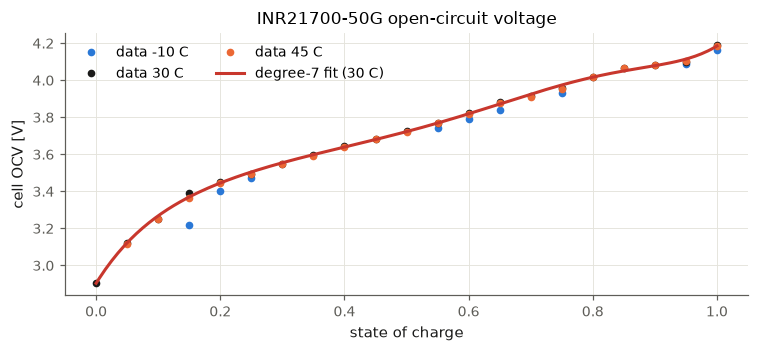

mean OCV over 0..1: 3.7044 V (exact polynomial integral; used for pack energy)


In [5]:
table = cells.load_ocv_table()
soc_data, ocv_data = table.at_temperature(30.0)
coefficients = cells.fit_ocv_polynomial(soc_data, ocv_data)
check("the OCV polynomial in battery_ecm.py is the least-squares fit to the 30 C data",
      onp.allclose(coefficients, inr21700_50g_ocv_model().coefficients, rtol=1e-8))
cell = inr21700_50g_cell()
soc = onp.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(7, 3.3))
for t_C, color in ((-10, blue), (25, aqua), (30, ink), (45, orange)):
    s_, v_ = table.at_temperature(float(t_C))
    if len(s_):
        ax.plot(s_, v_, "o", ms=4, color=color, label=f"data {t_C} C")
ax.plot(soc, cell.ocv_model.voltage_V(soc), color=red, lw=2, label="degree-7 fit (30 C)")
ax.set(xlabel="state of charge", ylabel="cell OCV [V]", title="INR21700-50G open-circuit voltage")
ax.legend(ncol=2); plt.tight_layout(); plt.show()
print(f"mean OCV over 0..1: {cell.ocv_model.mean_voltage_V(0.0, 1.0):.4f} V (exact polynomial integral; used for pack energy)")

**Resistance.** The circuit per cell is $V = \mathrm{OCV}(s) - v_1 - v_2 - I R_0$, with two RC branches ($\tau_1 = 8$ s, $\tau_2 = 43$ s).
Each resistance follows

$$R_k(s, T) = R_{k,\text{ref}}\; e^{a x + b x^2}\,\big(1 + c\,e^{-(s - 0.2)/w_\text{lo}} + d\,e^{(s - 0.8)/w_\text{hi}}\big),\qquad x = T_\text{ref}/T - 1$$

an Arrhenius-like temperature term and exponential rises toward empty and full. The constants are a global least-squares fit
(an `asb.Opti` problem in `cells.fit_resistance_model`, the kind of data-layer fit allowed outside sizing) to all 308 discharge
DC-resistance points of the paper's Fig. 8 (pulses of 2, 10, 30 and 180 s, six temperatures). The model's DC resistance for a
pulse of length $t$ is $R_0 + \sum R_k (1 - e^{-t/\tau_k})$:

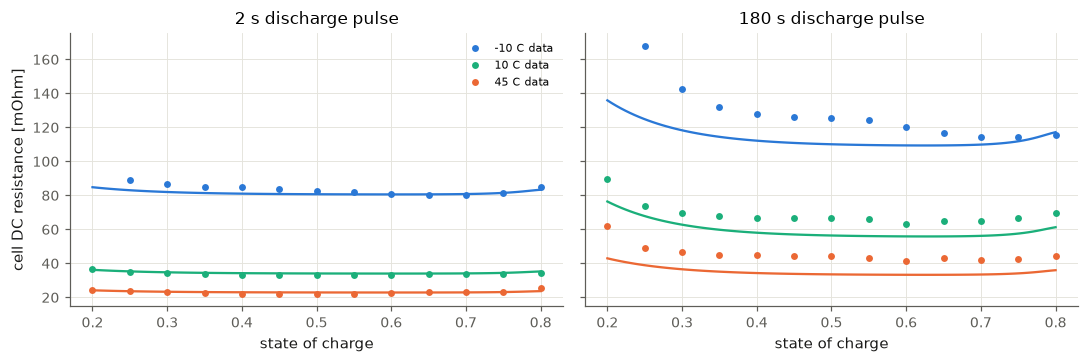

fit quality over 308 points: RMS 4.7%, max 21%
PASS  the hard-coded resistance model fits the DCIR data to about 5 % RMS


In [6]:
dcir = cells.load_dcir_table().select(discharge=True)
model = cell.resistance_model
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, duration_s in zip(axes, (2.0, 180.0)):
    for t_C, color in ((-10, blue), (10, aqua), (25, ink), (45, orange)):
        mask = (dcir.temperature_C == t_C) & (dcir.duration_pulse_s == duration_s)
        if mask.any():
            ax.plot(dcir.soc[mask], dcir.resistance_dc_ohm[mask] * 1e3, "o", ms=3.5, color=color, label=f"{t_C} C data")
            s_ = onp.linspace(0.2, 0.8, 100)
            ax.plot(s_, model.resistance_dc_ohm(s_, float(t_C), duration_s) * 1e3, color=color, lw=1.5)
    ax.set(xlabel="state of charge", title=f"{duration_s:.0f} s discharge pulse")
axes[0].set_ylabel("cell DC resistance [mOhm]"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()
target = cells.resistance_dc_corrected_ohm(dcir, cell.ocv_model, cell.capacity_As)
relative = model.resistance_dc_ohm(dcir.soc, dcir.temperature_C, dcir.duration_pulse_s) / target - 1
print(f"fit quality over {len(relative)} points: RMS {onp.sqrt(onp.mean(relative**2)):.1%}, max {onp.max(onp.abs(relative)):.0%}")
check("the hard-coded resistance model fits the DCIR data to about 5 % RMS", onp.sqrt(onp.mean(relative**2)) < 0.06)

(The OCV drift during a pulse is removed from the measured DCIR first, `resistance_dc_corrected_ohm`.) Long pulses see higher
resistance: the RC branches charge up. That is the polarization the engine-out hover feels.

## 4. The pack: `EquivalentCircuitBattery`

$N_s$ cells in series, $N_p$ strings in parallel ($N_p$ **continuous** in sizing):

| Quantity | Pack value |
|---|---|
| capacity | $N_p\,Q_\text{cell} \times$ `factor_capacity_ageing` |
| OCV | $N_s\,\mathrm{OCV}_\text{cell}(s)$ |
| resistances | $R_\text{cell} N_s / N_p \times$ `factor_resistance_ageing` / `factor_power_density` |
| current ratings | $N_p\,I_\text{cell,max} \times$ `factor_power_density` |
| voltage window | $N_s \times [2.5, 4.2]$ V |
| mass | $N_s N_p\, m_\text{cell}$ / `fraction_mass_cells` |

`factor_power_density` is an explicit, documented scaling assumption: the 50G's *shape* (OCV, the SOC and temperature dependence of R) with
the resistance divided by the factor, a cell as power-dense as the design needs. The Halo uses 5, with end-of-life ageing
(80 % capacity, +50 % resistance).

In [7]:
halo_pack = EquivalentCircuitBattery(count_series=210, count_parallel=24.0, factor_power_density=5.0,
                                     factor_capacity_ageing=0.8, factor_resistance_ageing=1.5)
limits = halo_pack.get_limits()
print(f"{halo_pack.count_cells:.0f} cells, {halo_pack.get_mass():.0f} kg, {halo_pack.energy_capacity_J / 3.6e6:.1f} kWh (aged), "
      f"window {limits.min_voltage_V:.0f}-{limits.max_voltage_V:.0f} V, max discharge {limits.max_discharge_current_A:.0f} A")
print("pack resistances at SOC 0.5, 25 C [ohm]:", onp.round(halo_pack.resistances_ohm(0.5), 4))

5040 cells, 497 kg, 73.2 kWh (aged), window 525-882 V, max discharge 1176 A
pack resistances at SOC 0.5, 25 C [ohm]: [0.0629 0.0047 0.043 ]


**Operating over an interval.** `evaluate(current_A, soc, duration_s, voltage_rc_start_V)` holds a constant current for the
interval and uses the exact solution of each RC branch, $v_k(t) = I R_k + (v_{k,0} - I R_k)e^{-t/\tau_k}$. It returns the
**interval-mean** terminal voltage (the bus voltage for that point's power balance), the **end** voltage (checked against the cell
cutoff), the end RC voltages (the next point's start), and the split $V = V^* - I R_\text{eff}$ that the branch constraint uses:

In [8]:
print(inspect.getsource(EquivalentCircuitBattery.evaluate))

    def evaluate(self, current_A, soc, duration_s=0.0, voltage_rc_start_V=None, temperature_C=None):
        soc_next = soc - current_A * duration_s / self.capacity_As
        soc_mid = (soc + soc_next) / 2
        voltage_open_circuit_V = self.voltage_open_circuit_V(soc_mid)
        resistance_0_ohm, *resistances_rc_ohm = self.resistances_ohm(soc_mid, temperature_C)
        time_constants_s = self.cell.resistance_model.time_constants_s()
        is_instant = isinstance(duration_s, (int, float)) and duration_s == 0
        voltage_rc_V, voltage_rc_end_V, offsets_V, slopes_ohm = [], [], [], []
        for k, (r_ohm, tau_s) in enumerate(zip(resistances_rc_ohm, time_constants_s)):
            steady_V = current_A * r_ohm
            if voltage_rc_start_V is None:
                # No history: polarization fully developed (steady state).
                mean_fraction, end_fraction, start_V = 0.0, 0.0, 0.0
            elif is_instant:
                mean_fraction, end_fraction, start_V = 1

Key details:

- OCV and resistances are taken at the **mid-interval SOC**, so a sub-segmented mission integrates $\int \mathrm{OCV}\,dQ$ to
  second order;
- `voltage_rc_start_V=None` means "polarization fully developed" (steady state, conservative for short pulses); missions start
  from rest, `(0.0, 0.0)`, and pass the RC state from point to point;
- nothing is clipped: SOC can go negative and the voltage can fall below the cutoff; the *caller* constrains SOC, current and
  voltage.

## 5. A pulse, numerically

Fly a sequence of constant-power intervals on the pack: a take-off hover, a cruise, then an engine-out hover from 30 % SOC.
Each interval's current solves its power equation (with the physical root), and the RC state carries over. This is
exactly what `build_mission` does symbolically:

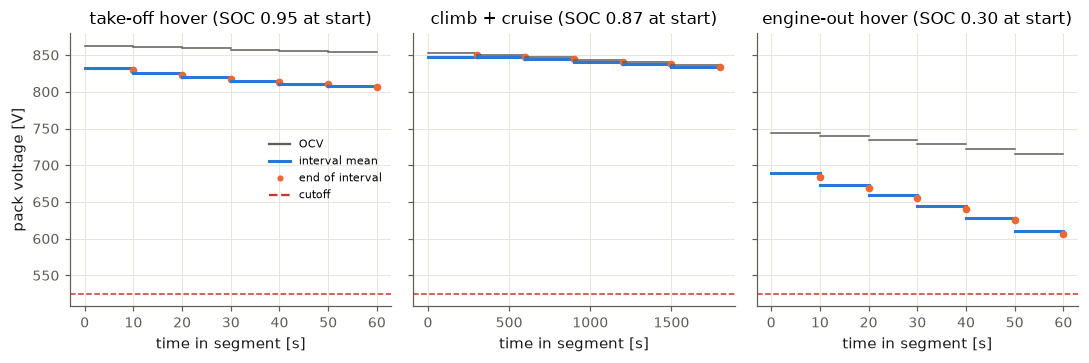

end of the engine-out hover: 606 V against the 525 V cutoff, SOC 0.158


In [9]:
def current_for(pack_, power_W, soc_, duration_s, rc_V):
    """The physical-root current that delivers power_W over the interval (closed form of the quadratic)."""
    probe = pack_.evaluate(0.0, soc_, duration_s, rc_V)                 # zero current gives V* and R_eff
    for _ in range(3):                                                  # mid-interval SOC depends weakly on I
        v_star, r_eff = probe.voltage_driving_V, probe.resistance_effective_ohm
        current = (v_star - onp.sqrt(v_star**2 - 4 * r_eff * power_W)) / (2 * r_eff)
        probe = pack_.evaluate(current, soc_, duration_s, rc_V)
    return current

segments = [("take-off hover", 60.0, 350e3, 6), ("climb + cruise", 1800.0, 20e3, 6), ("reserve to 30 %", 1.0, 0.0, 1),
            ("engine-out hover", 60.0, 520e3, 6)]
soc_, rc_V, t_s = 0.95, (0.0, 0.0), 0.0
trace = []
for label, duration_s, power_W, count in segments:
    if label.startswith("reserve"):
        soc_ = 0.30                                                     # the mission ends at the reserve SOC
        continue
    for _ in range(count):
        dt = duration_s / count
        current = current_for(halo_pack, power_W, soc_, dt, rc_V)
        state = halo_pack.evaluate(current, soc_, dt, rc_V)
        trace.append((t_s, t_s + dt, label, float(state.voltage_V), float(state.voltage_end_V), float(state.voltage_open_circuit_V),
                      current, soc_))
        soc_, rc_V, t_s = float(state.soc_next), tuple(float(v) for v in state.voltage_rc_end_V), t_s + dt
labels = ["take-off hover", "climb + cruise", "engine-out hover"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for ax, label in zip(axes, labels):
    rows = [row for row in trace if row[2] == label]
    t_start = rows[0][0]
    for t0, t1, _, v_mean, v_end, v_ocv, current, s0 in rows:
        ax.plot([t0 - t_start, t1 - t_start], [v_ocv, v_ocv], color=ink_muted, lw=1)
        ax.plot([t0 - t_start, t1 - t_start], [v_mean, v_mean], color=blue, lw=2)
        ax.plot(t1 - t_start, v_end, ".", color=orange, ms=8)
    ax.axhline(limits.min_voltage_V, color=red, ls="--", lw=1)
    ax.set(xlabel="time in segment [s]", title=f"{label} (SOC {rows[0][7]:.2f} at start)")
axes[0].set_ylabel("pack voltage [V]")
axes[0].plot([], [], color=ink_muted, label="OCV"); axes[0].plot([], [], color=blue, lw=2, label="interval mean")
axes[0].plot([], [], ".", color=orange, label="end of interval"); axes[0].plot([], [], "--", color=red, label="cutoff")
axes[0].legend(fontsize=7); plt.tight_layout(); plt.show()
v_end_last = trace[-1][4]
print(f"end of the engine-out hover: {v_end_last:.0f} V against the {limits.min_voltage_V:.0f} V cutoff, SOC {soc_:.3f}")

At 30 % SOC the OCV is low and the resistance high, and 60 s of high current charges the slow RC branch. The end voltage of the
last interval is what limits the pack.

## 6. Sizing the pack: energy or voltage?

Choose $N_p$ (continuous) for the lightest pack that (a) holds a mission's energy between 95 % and 30 % SOC and (b) delivers the
engine-out power for 60 s from 30 % SOC, in three sub-points like the Halo (`subsegments_engine_out = 3`), with the end voltage of every
sub-point above the cutoff and the current within its rating. Every current is a variable with its power equality and branch
constraint; the RC state propagates symbolically.

In [10]:
from aircraft_closure.core.margins import margin_above, margin_below, margin_report

def size_pack(power_engine_out_W, energy_mission_J, count_points=3, verbose=False):
    opti = asb.Opti()
    count_parallel = opti.variable(init_guess=30.0, scale=10.0, lower_bound=1.0)
    pack_ = replace(halo_pack, count_parallel=count_parallel)
    lim = pack_.get_limits()
    energy_window_J = pack_.capacity_As * pack_.count_series * pack_.cell.ocv_model.mean_voltage_V(0.30, 0.95) * (0.95 - 0.30)
    margins = [margin_above("mission energy_J", energy_window_J, energy_mission_J)]
    soc_k, rc_k = 0.30, None                                    # polarization developed at the start (conservative)
    dt = 60.0 / count_points
    for k in range(count_points):
        current = opti.variable(init_guess=300.0, scale=100.0)
        st = pack_.evaluate(current, soc_k, dt, rc_k)
        opti.subject_to([st.power_electric_W / power_engine_out_W == 1, st.voltage_V / st.voltage_driving_V >= 0.5])
        margins += [margin_above(f"engine-out {k + 1}/{count_points}: end voltage_V", st.voltage_end_V, lim.min_voltage_V),
                    margin_below(f"engine-out {k + 1}/{count_points}: discharge_current_A", current, lim.max_discharge_current_A)]
        soc_k, rc_k = st.soc_next, st.voltage_rc_end_V
    margins.append(margin_above("SOC after engine-out", soc_k, 0.10))
    opti.subject_to([m.value >= 0 for m in margins])
    opti.minimize(pack_.get_mass() / 100)
    s = opti.solve(verbose=verbose)
    return s.value(count_parallel), s.value(pack_.get_mass()), margin_report(margins, s.value)

count, mass, report = size_pack(520e3, 25 * 3.6e6)
print(f"N_p = {count:.2f} strings, {mass:.0f} kg")
for entry in report[:4]:
    print(f"   {entry.value:+.4f}  {entry.label}")
check("at this engine-out power the end-of-hover voltage, not the energy, sizes the pack",
      "end voltage" in report[0].label and abs(report[0].value) < 1e-6)

N_p = 19.84 strings, 411 kg
   -0.0000  engine-out 3/3: end voltage_V
   +0.0025  engine-out 3/3: discharge_current_A
   +0.0585  SOC after engine-out
   +0.0834  engine-out 2/3: discharge_current_A
PASS  at this engine-out power the end-of-hover voltage, not the energy, sizes the pack


Now sweep the engine-out power: at low power the energy requirement sizes the pack, above a crossover the voltage at the end of the
hover does, and the pack grows much faster than linearly because extra strings must lower the resistance, not add energy:

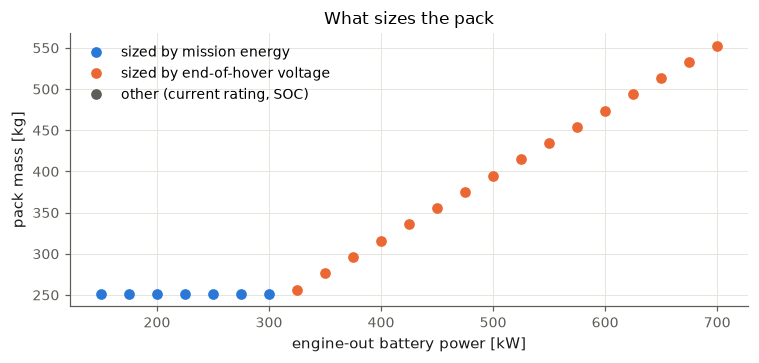

In [11]:
powers_kW = onp.linspace(150, 700, 23)
masses, drivers = [], []
for p in powers_kW:
    _, mass_kg, rep = size_pack(p * 1e3, 25 * 3.6e6)
    masses.append(mass_kg)
    drivers.append(rep[0].label)
fig, ax = plt.subplots(figsize=(7, 3.4))
for p, m_, d_ in zip(powers_kW, masses, drivers):
    ax.plot(p, m_, "o", color=orange if "voltage" in d_ else blue if "energy" in d_ else ink_muted)
ax.plot([], [], "o", color=blue, label="sized by mission energy"); ax.plot([], [], "o", color=orange, label="sized by end-of-hover voltage")
ax.plot([], [], "o", color=ink_muted, label="other (current rating, SOC)")
ax.set(xlabel="engine-out battery power [kW]", ylabel="pack mass [kg]", title="What sizes the pack")
ax.legend(); plt.tight_layout(); plt.show()

This is the Halo's battery story in miniature (README, "What sizes the aircraft": *the pack hits its cell voltage cutoff, so voltage sag,
not stored energy, sets its size*).

## 7. How the Halo builds its pack

In [12]:
import examples.halo_sizing as hs
print(inspect.getsource(hs.build_halo_battery))

def build_halo_battery(design, assumptions=HaloAssumptions()):
    a, d = assumptions, design
    if a.battery_model == "ecm":
        return EquivalentCircuitBattery(count_series=a.count_series_battery, count_parallel=d.count_parallel_battery,
                                        factor_power_density=a.factor_power_density_battery,
                                        temperature_cell_C=a.temperature_cell_battery_C,
                                        factor_capacity_ageing=a.factor_capacity_ageing_battery,
                                        factor_resistance_ageing=a.factor_resistance_ageing_battery,
                                        fraction_mass_cells=a.fraction_mass_cells_battery,
                                        min_soc=soc_emergency_floor, max_soc=soc_take_off, **battery_thermal(a))
    if a.battery_model == "constant":
        return Battery(energy_capacity_J=d.energy_capacity_battery_J,
                       resistance_ohm=a.resistance_energy_produ

The parallel count is a design variable (`HaloDesign.count_parallel_battery`); energy and power then follow from the pack. `min_soc` is the
emergency floor (0.10) and `max_soc` the take-off SOC (0.95). The mission holds the 30 % reserve floor at every segment end
(`soc_floor`), and the failure hovers start from it.

## Summary

- `Battery`: $V = V_\text{oc} - IR$; SOC follows chemical, not terminal, energy; mass is max(energy, power) sizing.
- A power demand gives two current roots; the flight point's `V >= V*/2` constraint selects the physical one and caps power at $V^{*2}/4R$.
- `EquivalentCircuitBattery`: 50G OCV polynomial and fitted R(SOC, T), R0 + 2 RC with exact interval solutions, pack scaling with
  continuous strings, ageing and a power-density factor; nothing clipped.
- Voltage at the end of a long, high-current, low-SOC pulse sizes the Halo's pack.

## Check yourself

<details><summary>1. Why is pack energy computed with the mean OCV over 0..1 rather than the nominal 3.6 V?</summary>

Energy is the integral of OCV over charge, $Q\int_0^1 \mathrm{OCV}(s)\,ds = Q\,\overline{\mathrm{OCV}}$. The polynomial's exact integral gives it; the nominal voltage is a datasheet convention, not the integral.
</details>

<details><summary>2. A mission point uses <code>voltage_rc_start_V=None</code>. What does that assume, and is it conservative?</summary>

That the polarization is fully developed (steady state, $v_k = IR_k$), as if the current had been held for several $\tau_2$. For short high-current pulses from rest it overestimates the sag: conservative. Missions start from rest and propagate the RC state instead.
</details>

<details><summary>3. Without the branch constraint, what could IPOPT report for a hover that needs more than the matched-load power?</summary>

The power equality has no real solution, so the problem is locally infeasible. Near the limit it may converge to the high-current root, with less than half the voltage at the terminals: a physically absurd operating point that satisfies all the equations.
</details>

In [13]:
check_summary()

7 of 7 checks passed
